<a href="https://colab.research.google.com/github/MonaKhadija/Data-Analytics-and-Artificial-Intelligence-Project-DAAI/blob/main/Project4_khadija_bassiouni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project 4: Unsupervised Image Clustering and Visualization:**



**1. Environment Setup:**

we will import the necessary libraries and load the MNIST dataset using Scikit-learn's fetch_openml function:

In [1]:
# Importing necessary libraries
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
# Loading MNIST dataset

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target

In [3]:
# Checking the size and properties of the data
print("Shape:", X.shape)
print("Data type:", X.dtype)
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Shape: (70000, 784)
Data type: int64
Minimum pixel value: 0
Maximum pixel value: 255


**2. Explore and Normalize the Images:**

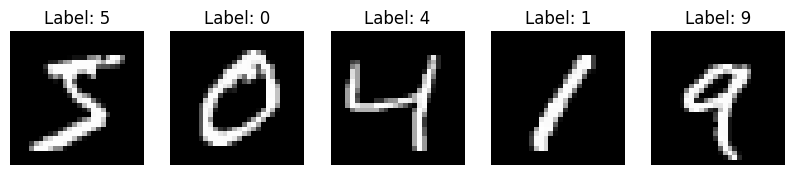

Normalized Minimum pixel value: 0.0
Normalized Maximum pixel value: 1.0


In [4]:
# Displaying sample images
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
    ax.set_title(f"Label: {y[i]}")
plt.show()

# Normalizing pixel values
X = X / 255.0
print("Normalized Minimum pixel value:", X.min())
print("Normalized Maximum pixel value:", X.max())

**3. Sampling the Data and Running the Elbow Method:**

Finished K=5, Inertia: 432527.7509384551
Finished K=10, Inertia: 390343.0628082017
Finished K=15, Inertia: 365525.2325064674


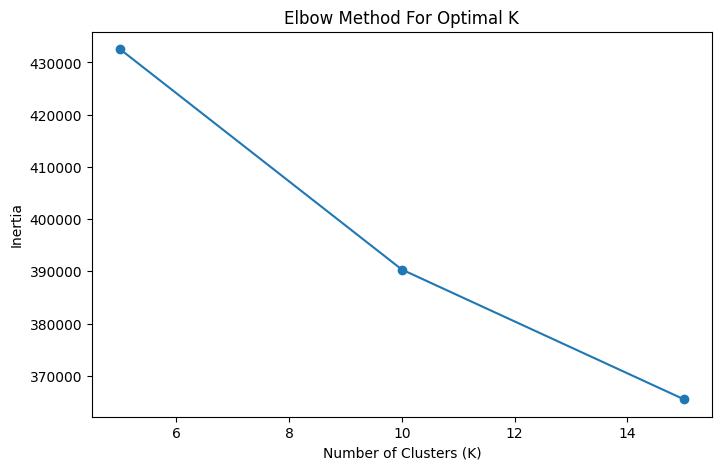

In [5]:
# Using a sample of 10,000 images with a fixed random seed
rng = np.random.RandomState(42)
sample_indices = rng.choice(len(X), size=10000, replace=False)
X_sample = X[sample_indices]
y_sample = y[sample_indices]

# Finding a reasonable number of clusters using the elbow method
inertia = []
k_values = [5, 10, 15]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    inertia.append(kmeans.inertia_)
    print(f"Finished K={k}, Inertia: {kmeans.inertia_}")

# Ploting the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method For Optimal K")
plt.show()

**4. Training the Final K-Means Model:**

In [6]:
# Training final K-Means model with K=10
k_final = 10
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_sample)

# Checking cluster sizes
cluster_sizes = pd.Series(clusters).value_counts().sort_index()
print("Cluster Sizes:\n", cluster_sizes)

Cluster Sizes:
 0     519
1     757
2    1487
3    1039
4    1475
5    1331
6     513
7     906
8    1017
9     956
Name: count, dtype: int64


**5. Understand the Clusters via Centroids:**

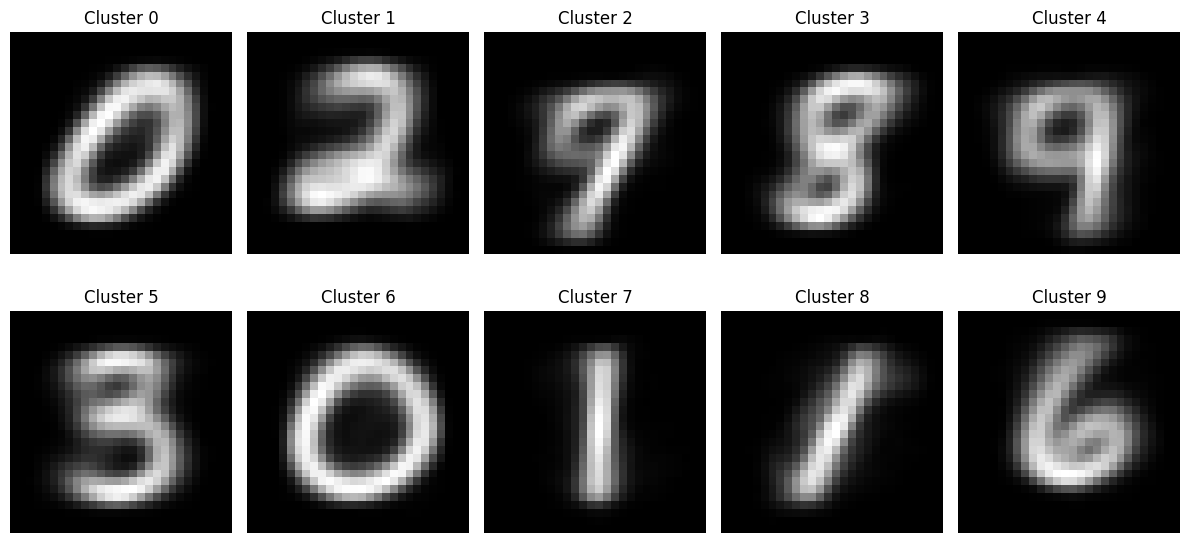

In [7]:
# Displaying all cluster centroids as images
centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(centroids[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
    ax.set_title(f"Cluster {i}")
plt.tight_layout()
plt.show()

**6. Compare Clusters with Actual Digit Labels:**

In [8]:
# Create a cross-tabulation table comparing clusters and actual digit labels
crosstab = pd.crosstab(clusters, y_sample)
print(crosstab)

col_0    0    1    2    3    4    5    6    7    8    9
row_0                                                  
0      427    0   11   17    0   39   14    1    7    3
1        5    1  666   42    8    4   10    9   12    0
2        4    1    8    7  290   57    1  654   23  442
3       22    2   20  146    4  266    9    1  560    9
4        3    4   26   33  500   63   14  295   34  503
5       31    5   71  700    0  310    4    0  197   13
6      458    0    5    2    2    5   26    2    6    7
7        0  642   45   55   16   18   34   34   32   30
8        2  497   70   24   49  155   48   57   87   28
9       31    0   45    8   37   20  801    2   11    1


**7. Visualize Clusters Using PCA:**

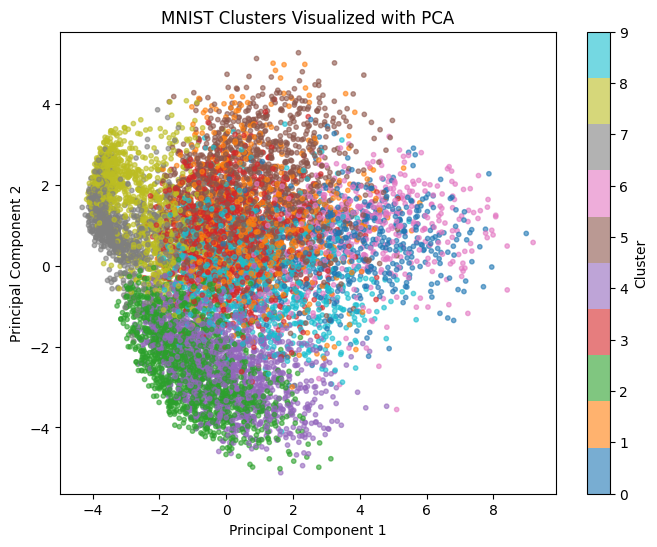

In [9]:
# Reducing dimensions to 2 using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# Creating a scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=10, alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST Clusters Visualized with PCA")
plt.colorbar(scatter, label="Cluster")
plt.show()

**8. Predict Clusters for New Images:**

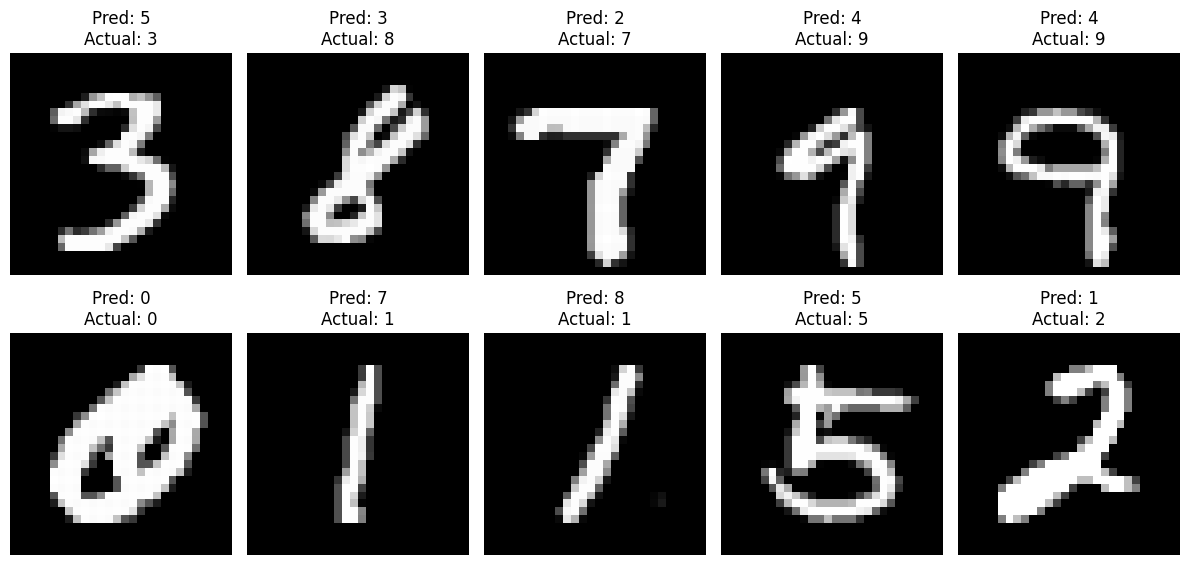

In [10]:
# we select 10 new images that were not used to train K-Means
X_new = X[10000:10010]
y_new = y[10000:10010]

# we predict their clusters
new_clusters = kmeans.predict(X_new)

# let's display the new images alongside their predicted clusters and actual labels
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_new[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
    ax.set_title(f"Pred: {new_clusters[i]}\nActual: {y_new[i]}")
plt.tight_layout()
plt.show()